In [1]:
import sys
sys.path.append('../')

from spicy_snow.retrieval import retrieve_snow_depth
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.utils.download import download_urls, download_urls_parallel
from spicy_snow.processing.generate_dataarrays import generate_sentinel1_dataarray, generate_snowcover_dataarray, generate_forest_fraction_dataarray, convert_snowcover_dates_to_s1_overpasses

import pandas as pd
from spicy_snow.utils.raster import tif_to_dataarray, combine_close_images, da_to01
from spicy_snow.utils.checks import validate_aoi, within_conus, validate_urls

import xarray as xr

In [13]:
test_start_date = '2020-02-01'
test_stop_date = '2020-03-01'
dates = [test_start_date, test_stop_date]
test_aoi = [-114.5, 43, -114, 44]
aoi = test_aoi
ref = None

In [3]:
from spicy_snow.processing.generate_dataarrays import generate_sentinel1_zarr, combine_close_images, generate_sentinel1_dataarray, init_output_zarr
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.utils.download import download_urls, download_urls_parallel


from pathlib import Path
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')
# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)
s1_urls = [u for u in s1_urls if u.endswith(('_VV.tif', '_VH.tif', '_mask.tif'))]
s1_fps = download_urls_parallel(s1_urls, work_dir.joinpath('opera'))
vv = generate_sentinel1_zarr(s1_fps, aoi, 'vv', '/Users/zmhoppinen/Documents/spicy-snow/local/test.zarr')
# vv = generate_sentinel1_dataarray(s1_fps, aoi, 'vv')

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Merging s1 tifs for vv: 100%|██████████| 85/85 [00:03<00:00, 23.51it/s]


In [16]:
import numpy as np
import pandas as pd
import xarray as xr
first_fp = s1_fps[0]
resolution = (100, 100)
pol = 'vv'

In [48]:
times = []
tracks = []
# First pass — collect timestamps
pol_fps = [f for f in s1_fps if f.stem.lower().endswith(pol)]
for fp in pol_fps:
    if fp.stem.lower().endswith(pol):
        t = pd.to_datetime(fp.stem.split('_')[4], format='%Y%m%dT%H%M%SZ')
        times.append(t)

        track = int(fp.stem.split('_')[3].split('-')[0][1:])
        tracks.append(track)

from shapely.geometry import box
# Build reference grid from first file
if ref is None:
    first_fp = s1_fps[0]
    ref = xr.open_dataarray(first_fp, chunks="auto")[0]
    assert ref.rio.crs.is_projected, f'Unable to set spatial resolution with non-projected crs: {ref.rio.crs}'

    ref = ref.rio.reproject(dst_crs=ref.rio.crs, resolution=resolution)
    ref = ref.rio.reproject("EPSG:4326")
    ref = ref.rio.clip_box(*box(*aoi).bounds).rio.pad_box(*box(*aoi).bounds)


In [49]:
zarr_path = '/Users/zmhoppinen/Documents/spicy-snow/local/simple.zarr'
path = Path(zarr_path)

y = ref["y"]
x = ref["x"]

data = np.zeros(
    (len(times), len(y), len(x)),
    dtype=ref.dtype,
)

da = xr.DataArray(
    data,  # the actual array: shape (time, y, x)
    dims=("time", "y", "x"),
    coords={
        "time": times,
        "y": y,
        "x": x,
        "track": ("time", tracks),
        # "platform": ("time", platforms),  # optional
    },
    name=pol,  # name of the variable
)

da.to_zarr(path, mode="w")

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [50]:
from tqdm import tqdm
# Write slices one-by-one
for fp, time in tqdm(zip(pol_fps, times, strict = True), desc=f"Merging s1 tifs for {pol}", total = len(times)):
    img = xr.open_dataarray(fp, chunks="auto")[0]
    img = img.rio.reproject_match(ref)
    da.loc[dict(time = time)] = img


Merging s1 tifs for vv: 100%|██████████| 85/85 [00:04<00:00, 20.26it/s]


In [57]:
da

<xarray.DataArray 'vv' (time: 85, y: 372, x: 1056)> Size: 134MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(85, 372, 1056), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 680B 2020-02-23T13:49:15 ... 2020-02-01T01...
  * y        (y) float64 3kB 43.66 43.65 43.65 43.65 ... 43.22 43.22 43.22 43.22
  * x        (x) float64 8kB -115.2 -115.2 -115.2 ... -114.0 -114.0 -114.0
    track    (time) int64 680B 71 71 20 20 71 20 20 93 ... 93 93 93 93 93 93 93

In [55]:
combine_close_images(da)

ValueError: 'track' not present in all datasets and coords='different'. Either add 'track' to datasets where it is missing or specify coords='minimal'.

In [34]:
da.loc[dict(time = '2020-02-23T13:49:15')] = ref

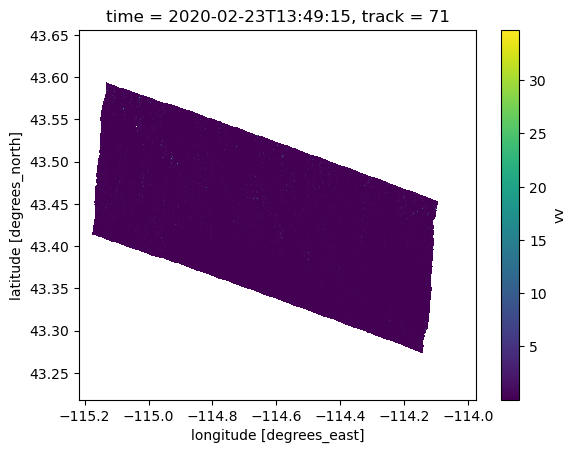

In [35]:
da.sel(time = '2020-02-23T13:49:15').plot()

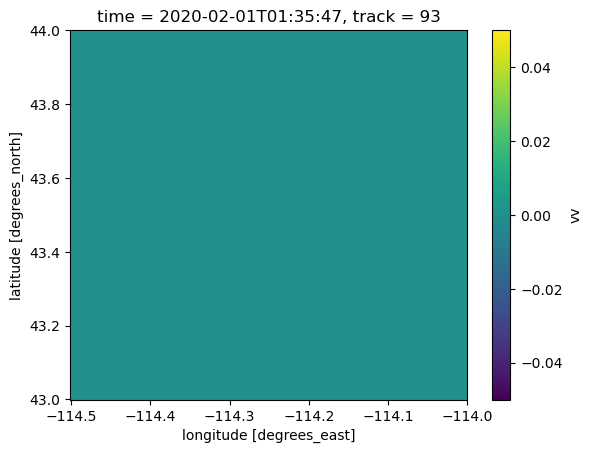

In [7]:
import numpy as np
# combine_close_images(vv)[1].plot()
vv[2].plot()

In [5]:
import dask
import numpy as np
test = dask.array.zeros((10, 100, 100), chunks = 'auto', dtype = np.float32)
test_da = xr.DataArray(test, dims = ("time", 'y', 'x'))
test_da.to_zarr('/Users/zmhoppinen/Documents/spicy-snow/local/simple.zarr', mode="w")
img = xr.DataArray(np.random.random((100, 100)), dims = ['y', 'x'])
test_da[0, :, :] = img
np.array(test_da[0, :, :])

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


array([[0.97292167, 0.73370916, 0.69500005, ..., 0.266064  , 0.10818571,
        0.7072964 ],
       [0.6323562 , 0.64142877, 0.6209079 , ..., 0.24328804, 0.45761207,
        0.9111771 ],
       [0.2687919 , 0.96082175, 0.60421264, ..., 0.92687184, 0.3521148 ,
        0.34405205],
       ...,
       [0.7564707 , 0.88270426, 0.8140638 , ..., 0.98684746, 0.18640639,
        0.3378928 ],
       [0.7501677 , 0.99936646, 0.2201126 , ..., 0.57995975, 0.09564546,
        0.9527472 ],
       [0.55823   , 0.13964151, 0.93462944, ..., 0.6075745 , 0.8605585 ,
        0.24142414]], shape=(100, 100), dtype=float32)

In [6]:
fasdlkjfsa

NameError: name 'fasdlkjfsa' is not defined

In [ ]:
retrieval = retrieve_snow_depth(test_aoi, [test_start_date, test_stop_date], work_dir= '/Users/zmhoppinen/Documents/spicy-snow/local')

(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "platform": [
        "SENTINEL-1A",
        "SENTINEL-1C",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-02-01T00:00:00Z",
    "end": "2020-03-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "start": "2020-02-01T00:00:00Z",
    

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Merging s1 tifs for vv:  25%|██▍       | 21/85 [00:01<00:04, 13.21it/s]


KeyboardInterrupt: 

In [ ]:
pol = 'vv'
chunks = 'auto'
ref = None
spatial_resolution = (100, 100)
aoi = validate_aoi(aoi)
da_list = []
times = []

from tqdm import tqdm
for fp in tqdm(s1_fps, desc = 'Merging datasets'):
    if fp.stem.lower().endswith(pol):
            time = pd.to_datetime(fp.stem.split('_')[4], format = '%Y%m%dT%H%M%SZ')
            track = int(fp.stem.split('_')[3].split('-')[0][1:])
            satellite_number = fp.stem.split('_')[6]
            mask_fp = fp.parent.joinpath(f'{fp.stem[:-3]}_mask.tif')
            if mask_fp.exists():
                mask = xr.open_dataarray(mask_fp, chunks=chunks)[0]
                # section 4.3 https://d2pn8kiwq2w21t.cloudfront.net/documents/ProductSpec_RTC-S1.pdf
                # 0 = not affected by layover or shadow
                mask = mask.where(mask == 0)
            
            da = xr.open_dataarray(fp, chunks = chunks)[0]
            if ref is None:
                assert da.rio.crs.is_projected, f'Unable to set spatial resolution with non-projected crs: {da.rio.crs}'
                ref = da.rio.reproject(dst_crs = da.rio.crs, resolution=spatial_resolution)
                ref = ref.rio.reproject('EPSG:4326')
                ref = ref.rio.clip_box(*aoi.bounds)
                ref = ref.rio.pad_box(*aoi.bounds)
            else:
                da = da.rio.reproject_match(ref)

            da = da.expand_dims(time = [time])
            # add relative orbit information
            da = da.assign_coords(track = ('time', [track]))
            # add satellite information
            da = da.assign_coords(platform = ('time', [satellite_number]))

            da_list.append(da)
            times.append(time)

y = ref["y"]
x = ref["x"]

# Dask array placeholder
data = da.zeros(
    (len(da_list), len(y), len(x)), 
    chunks=(1, "auto", "auto"),
    dtype=ref.dtype)

ds = xr.Dataset(
    {pol: (("time", "y", "x"), data)},
    coords=dict(
        time=("time", times),
        y=y,
        x=x,))

# concatenate along time dimension
stacked = xr.concat(da_list, dim='time').sortby('time')

# next stack close times spatially
stacked = combine_close_images(stacked)
stacked.name = pol


Merging datasets: 100%|██████████| 255/255 [00:04<00:00, 53.49it/s]


AttributeError: 'DataArray' object has no attribute 'zeros'

In [ ]:
# generate dataset and start to save s1 data vars
ds = xr.Dataset()
ds['vv'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VV')

# grab spatial reference from first time step of VV
spatial_reference = ds['vv'].isel(time =0)

ds['vh'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VH', ref = spatial_reference)

# download viirs snow cover fraction for each sentinel 1 overpass date
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = aoi)
snowcover_fps = download_urls(snowcover_urls, work_dir.joinpath('snowcover'))

# generate snow cover dataset
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)

# resample date times from each day to the exact s1 overpass time. Doubles if two in one day
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])


(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.5000000000000000))",
    "platform": [
        "SENTINEL-1C",
        "SENTINEL-1A",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-01-11T00:00:00Z",
    "end": "2020-01-18T00:00:00Z"
}
(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow spicy_snow.utils.spicy_logging INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.50

(spicy-snow spicy_snow.utils.spicy_logging INFO) Granules found: 2
(spicy-snow spicy_snow.utils.spicy_logging INFO) Granules found: 2


In [ ]:
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = test_aoi)
snowcover_fps = download_urls(snowcover_urls, '/Users/zmhoppinen/Documents/spicy-snow/local/snowcover')
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])
# table 1 https://nsidc.org/sites/default/files/documents/user-guide/multi_vnp10a1f-v002-userguide.pdf
ds['watermask'] = (viirs_snowcover == 237).median('time')
ds['snowcover'] = viirs_snowcover.where(viirs_snowcover <= 100) > 10

KeyboardInterrupt: 

In [ ]:
ds['snowcover']

<xarray.DataArray 'snowcover' (time: 3, y: 1473, x: 1473)> Size: 7MB
array([[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]]],
      shape=(3, 1473, 1473))
Coordinates:
  * time         (time) datetime64[ns] 24B 2020-01-11T01:59:43.333332992 ... ...
  * y            (y) float64 12kB 41.0 41.0 41.0 41.0 ... 40.5 40.5 40.5 40.5
  * x            (x) float64 12kB -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
    band         int64 8B 1
    spatial_ref  int64 8B 0
    track        (time) int64 24B 137 137 144
    platform     (time) <U3 36B 'S1B' 'S1A' 'S1A'

In [ ]:
ds['fcf'] = generate_forest_fraction_dataarray(test_aoi, ref = spatial_reference)

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


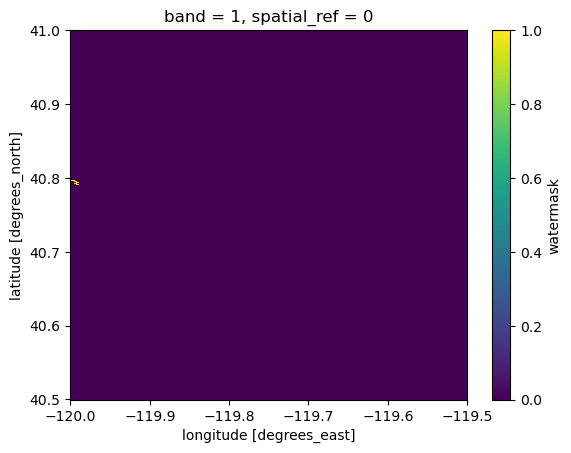

In [ ]:
ds['watermask'].median('time').plot()

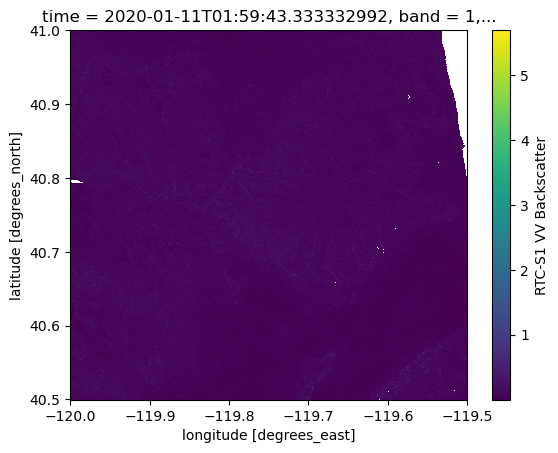

In [ ]:
ds['vv'].where(~ds['watermask'])[0].plot()